# DataProjectLab - Projet Sante
## Prevision de la demande en medicaments
### Notebook 2 - Analyse SQL & Exploration Python (EDA)
### VERSION CORRIGEE - Mode formateur

---

> **Comment lire ce notebook :**
> Chaque requete SQL et chaque bloc Python sont precedes d'une explication du POURQUOI.
> Les blocs `METHODE` expliquent les choix techniques et les patterns SQL/Python.
> Les blocs `INTERPRETATION` lisent les resultats pour le Dr. Konan.
> Les blocs `CLINIQUE` font le lien entre le chiffre et la realite medicale.

---

| Info | Detail |
|---|---|
| **Prerequis** | Notebook 1 complete - 6 CSV charges et explores |
| **Objectif** | Analyser les consommations, detecter les saisonnalites, evaluer les fournisseurs |
| **Sortie** | `df_features.csv` pret pour le ML (Notebook 3) |
| **Duree estimee** | 3h a 4h |
| **Competences** | DuckDB/SQL, EDA, feature engineering temporel, sin/cos cyclique |

---

### Plan du notebook

```
PARTIE A - SQL avec DuckDB
  Tache 1 : Vue d'ensemble (totaux, top medicaments quantite et cout)
  Tache 2 : Saisonnalite mensuelle + effet weekend
  Tache 3 : Window function - top medicament par service
  Tache 4 : Ruptures + performance reelle des fournisseurs

PARTIE B - Exploration Python (EDA)
  Tache 5 : Fusion dataset + audit qualite
  Tache 6 : 3 visualisations analytiques (heatmap, semaine/weekend, retards)
  Tache 7 : Feature engineering pour le ML
```

---

# Configuration & Chargement DuckDB

> **METHODE - Pourquoi DuckDB plutot que SQLite ou pandas pour les requetes SQL ?**
>
> DuckDB est un moteur SQL analytique in-process (pas de serveur a installer).
> Il lit directement les CSV avec `read_csv_auto` - pas besoin d'importer les donnees.
> Sa syntaxe est proche de PostgreSQL : `DATE_TRUNC`, `DAYOFWEEK`, `NULLIF`...
> Ce qu'on ecrit ici se transfere directement a SQL Server ou PostgreSQL en production.
>
> **`read_csv_auto` vs `read_csv` :**
> `read_csv_auto` detecte automatiquement les types (dates, entiers, flottants).
> `read_csv` necessite de specifier manuellement les types.
> Pour ce projet, `read_csv_auto` suffit car les CSV ont une structure claire.
>
> **Verification immediate apres connexion :**
> On verifie que les tables sont bien chargees avec un `COUNT(*)` avant d'analyser.
> Si le compte est 0 ou different de ce qu'on attend, on detecte le probleme
> immediatement plutot qu'apres 10 requetes d'analyse vides.

In [26]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"#F8F8F6",
                     "axes.grid":True,"grid.alpha":0.4,"font.size":11})

COLORS = {"primary":"#185FA5","secondary":"#1D9E75","warning":"#BA7517",
          "danger":"#E24B4A","neutral":"#888780","light":"#D3D1C7"}

con = duckdb.connect()
con.execute("""
    CREATE TABLE medicaments   AS SELECT * FROM read_csv_auto('dataset/medicaments.csv');
    CREATE TABLE services      AS SELECT * FROM read_csv_auto('dataset/services.csv');
    CREATE TABLE fournisseurs  AS SELECT * FROM read_csv_auto('dataset/fournisseurs.csv');
    CREATE TABLE consommations AS SELECT * FROM read_csv_auto('dataset/consommations.csv');
    CREATE TABLE commandes     AS SELECT * FROM read_csv_auto('dataset/commandes_fournisseurs.csv');
    CREATE TABLE ruptures      AS SELECT * FROM read_csv_auto('dataset/ruptures_stock.csv');
""")

print("6 tables DuckDB pretes")
print(f"  consommations : {con.execute('SELECT COUNT(*) FROM consommations').fetchone()[0]:,} lignes")
print(f"  commandes     : {con.execute('SELECT COUNT(*) FROM commandes').fetchone()[0]:,} lignes")
print(f"  ruptures      : {con.execute('SELECT COUNT(*) FROM ruptures').fetchone()[0]:,} lignes")

6 tables DuckDB pretes
  consommations : 53,808 lignes
  commandes     : 964 lignes
  ruptures      : 85 lignes


---

# PARTIE A - Analyse SQL avec DuckDB

> **METHODE - Pourquoi SQL avant Python dans ce notebook ?**
>
> En entreprise, les donnees vivent dans des bases de donnees.
> SQL est le langage commun entre les Data Analysts, les Data Engineers
> et les equipes metier. Ecrire la logique d'abord en SQL garantit
> que n'importe qui dans l'equipe peut re-utiliser et valider ces calculs.
>
> Python sera utilise ensuite pour ce que SQL ne peut pas faire facilement :
> visualisations avancees, machine learning, et transformations iteratives.

---

## Tache 1 - Vue d'ensemble des consommations

> **METHODE - Commencer par les ordres de grandeur : 'Est-ce que mes chiffres ont du sens ?'**
>
> Cette question est la premiere que doit poser tout analyste sur un nouveau jeu de donnees.
> Avant d'aller dans les details, on verifie que les aggregats globaux sont plausibles.
>
> Si le cout total est 10 fois superieur au budget annuel de l'hopital,
> c'est une erreur dans les donnees ou dans la requete - pas un insight.
> Si le nombre de medicaments distincts est 3 au lieu de 25, `read_csv_auto`
> a probablement mal parse la colonne `id_medicament`.
>
> Ces verifications prennent 30 secondes et evitent des heures d'analyse incorrecte.

In [27]:
# Requete 1a : Totaux generaux - verification des ordres de grandeur
df_totaux = con.execute("""
    SELECT
        COUNT(DISTINCT date)           AS nb_jours_donnees,
        COUNT(DISTINCT id_medicament)  AS nb_medicaments,
        COUNT(DISTINCT id_service)     AS nb_services,
        SUM(quantite_consommee)        AS total_unites,
        ROUND(SUM(cout_euro), 2)       AS cout_total_eur,
        ROUND(AVG(quantite_consommee), 2) AS conso_moy_par_ligne
    FROM consommations
""").df()

print("TOTAUX GENERAUX")
print("=" * 55)
for col in df_totaux.columns:
    val = df_totaux[col].iloc[0]
    print(f"  {col:<30} : {val:>12,}")

TOTAUX GENERAUX
  nb_jours_donnees               :          912
  nb_medicaments                 :           22
  nb_services                    :           10
  total_unites                   :    390,121.0
  cout_total_eur                 :  3,986,552.9
  conso_moy_par_ligne            :         7.25


### INTERPRETATION - Les ordres de grandeur

> **`nb_jours_donnees` vs duree theorique :**
> 30 mois x 30.4 jours/mois = ~912 jours theoriques.
> Si `nb_jours_donnees` est proche de 912, les donnees sont continues (peu de gaps).
> Si significativement inferieur, il y a des periodes sans consommation enregistree
> - potentiellement des weekends sans saisie, ou des periodes de maintenance du systeme.
>
> **`nb_medicaments` = 22 et `nb_services` = 10 :**
> Les donnees contiennent 22 medicaments distincts (sur les 25 du referentiel).
> 3 medicaments du referentiel n'ont donc aucune consommation enregistree sur la periode.
> A verifier avant de modeliser : sont-ils nouveaux (pas encore prescrits) ou
> simplement absents de ce jeu de donnees ? Ils seront exclus du modele ML faute
> de donnees historiques.
> `nb_services = 10` confirme que la jointure avec `services` sera complete.
>
> **`cout_total_eur` :**
> Divise par 30 mois = budget mensuel moyen en medicaments.
> Ce chiffre doit etre compare au budget alloue par la direction de l'hopital.
> S'il depasse le budget, l'analyse des categories les plus couteuses
> devient une priorite operationnelle immediate.
>
> **`conso_moy_par_ligne` :**
> La consommation moyenne par ligne (un medicament dans un service un jour).
> Si cette valeur est tres faible (< 5 unites), la consommation est sporadique.
> Si elevee (> 50 unites), certains medicaments sont consommes en masse.
> Ces extremes influencent directement le choix du modele de prevision.

### Top 10 medicaments par quantite vs par cout

> **METHODE - Analyser systematiquement les deux dimensions : volume ET valeur.**
>
> Un medicament tres consomme en volume peut avoir un impact financier modeste
> s'il est peu couteux a l'unite (ex : paracetamol).
> Un medicament rarement consomme peut dominer le budget s'il est tres couteux
> (ex : anticancereux, biotherapies).
>
> Pour le Dr. Konan, les deux listes sont importantes pour des raisons differentes :
> - Top volume : logistique et gestion physique des stocks
> - Top cout : budget et priorite de negociation avec les fournisseurs
>
> **La sous-requete scalaire dans le SELECT :**
> `SUM(c.cout_euro) / (SELECT SUM(cout_euro) FROM consommations) * 100`
> divise le cout de chaque medicament par le cout total pour obtenir un pourcentage.
> C'est une **sous-requete scalaire** : elle retourne une seule valeur
> qui sert de denominateur pour chaque ligne du resultat principal.

In [28]:
df_top_qte = con.execute("""
    SELECT
        m.nom,
        m.categorie,
        m.medicament_critique,
        SUM(c.quantite_consommee)           AS total_unites,
        ROUND(SUM(c.cout_euro), 0)          AS cout_total_eur,
        ROUND(AVG(c.quantite_consommee), 1) AS moy_par_jour
    FROM consommations c
    JOIN medicaments m ON c.id_medicament = m.id_medicament
    GROUP BY m.nom, m.categorie, m.medicament_critique
    ORDER BY total_unites DESC
    LIMIT 10
""").df()

df_top_cout = con.execute("""
    SELECT
        m.nom,
        m.prix_unitaire_euro,
        SUM(c.quantite_consommee)   AS total_unites,
        ROUND(SUM(c.cout_euro), 0)  AS cout_total_eur,
        ROUND(
            SUM(c.cout_euro) / (SELECT SUM(cout_euro) FROM consommations) * 100
        , 1)                         AS pct_budget
    FROM consommations c
    JOIN medicaments m ON c.id_medicament = m.id_medicament
    GROUP BY m.nom, m.prix_unitaire_euro
    ORDER BY cout_total_eur DESC
    LIMIT 10
""").df()

print("TOP 10 - MEDICAMENTS LES PLUS CONSOMMES (QUANTITE)")
print(df_top_qte.to_string(index=False))
print("\nTOP 10 - MEDICAMENTS LES PLUS COUTEUX")
print(df_top_cout.to_string(index=False))

top3_pct = df_top_cout["pct_budget"].head(3).sum()
print(f"\nInsight : les 3 premiers medicaments representent {top3_pct:.1f}% du budget total")

TOP 10 - MEDICAMENTS LES PLUS CONSOMMES (QUANTITE)
               nom           categorie  medicament_critique  total_unites  cout_total_eur  moy_par_jour
    Paracétamol 1g         Analgésique                 True      69394.00        55515.00          8.50
   Héparine 5000UI       Anticoagulant                 True      36914.00       812108.00          8.10
 Dexaméthasone 4mg          Corticoïde                 True      35707.00       242808.00          6.50
    Amlodipine 5mg    Antihypertenseur                 True      24735.00        79152.00          9.00
Amoxicilline 500mg        Antibiotique                 True      21244.00        53110.00          5.80
Atorvastatine 20mg       Hypolipémiant                 True      19823.00        83257.00          7.20
 Insuline Glargine      Antidiabétique                 True      19153.00       861885.00         10.50
    Ceftriaxone 1g        Antibiotique                 True      18787.00       225444.00          6.90
  Salbutamol 

### INTERPRETATION - Top quantite vs Top cout

> **Tous les medicaments du top 10 quantite sont critiques (`True`).**
>
> Aucun medicament non critique n'apparait dans le top 10 des volumes.
> Cela confirme que les medicaments critiques ne sont pas seulement
> vitaux cliniquement — ils sont aussi les plus consommes operationnellement.
> La priorite du systeme de prevision est donc parfaitement alignee :
> bien prevoir les critiques = bien prevoir l'essentiel de l'activite.

> **La divergence entre classement volume et classement cout est frappante.**
>
> Le Paracetamol 1g domine le volume (69 394 unites) mais est absent
> du top 10 cout — il coute seulement 0.80 euro l'unite (55 515 / 69 394).
> A l'inverse, l'Insuline Glargine est 7eme en volume mais 1ere en cout
> (861 885 euros = 45 euros l'unite x 19 153 unites).
>
> | Medicament | Volume | Rang cout | Prix unitaire |
> |---|---|---|---|
> | Paracetamol 1g | #1 | hors top | ~0.80 € |
> | Insuline Glargine | #7 | #1 | 45.00 € |
> | Erythropoietine | hors top | #3 | 85.00 € |

> **Les 3 premiers medicaments en cout = 57.3% du budget total.**
>
> Insuline (21.6%) + Heparine (20.4%) + Erythropoietine (15.3%) = 57.3%.
> Trois medicaments concentrent plus de la moitie du budget pharmacie.
> Une rupture sur l'un d'eux n'est pas seulement un risque clinique —
> c'est aussi un impact financier immediat sur le budget de l'hopital
> si on doit se sourcer en urgence a prix spot chez un fournisseur alternatif.

> **CLINIQUE - Ce qu'on dit au Dr. Konan :**
>
> 'Votre budget medicaments est concentre sur 3 references : Insuline,
> Heparine et Erythropoietine. Une erreur de prevision de 20% sur ces 3
> medicaments represente ~170 000 euros de surstockage ou de rupture.
> Notre modele ML traitera ces 3 references avec la precision la plus
> elevee et des seuils d'alerte de commande plus conservateurs.'

---

## Tache 2 - Saisonnalite mensuelle et effet weekend

> **METHODE - La saisonnalite est LA variable la plus importante pour le modele ML.**
>
> Si on ne detecte pas la saisonnalite ici, le modele sera mal calibre.
> Un modele qui ignore que janvier a une consommation systematiquement plus elevee
> sous-estimera les stocks necessaires en janvier - ce qui provoquera des ruptures
> exactement au moment ou la demande est la plus forte.
>
> **`DATE_TRUNC('month', date)` :**
> Tronque une date au debut du mois. Le 15 mars 2023 devient le 1er mars 2023.
> Toutes les dates du meme mois se retrouvent dans le meme groupe.
> Equivalent pandas : `df['date'].dt.to_period('M')`.
>
> **Le graphique en deux parties :**
> - Partie haute : evolution chronologique avec tendance lineaire
> - Partie basse : profil saisonnier (consommation moyenne par mois de l'annee)
>
> Ces deux vues repondent a deux questions differentes :
> 'Est-ce qu'on consomme de plus en plus ?' (tendance)
> 'Quels mois sont systematiquement plus intenses ?' (saisonnalite)

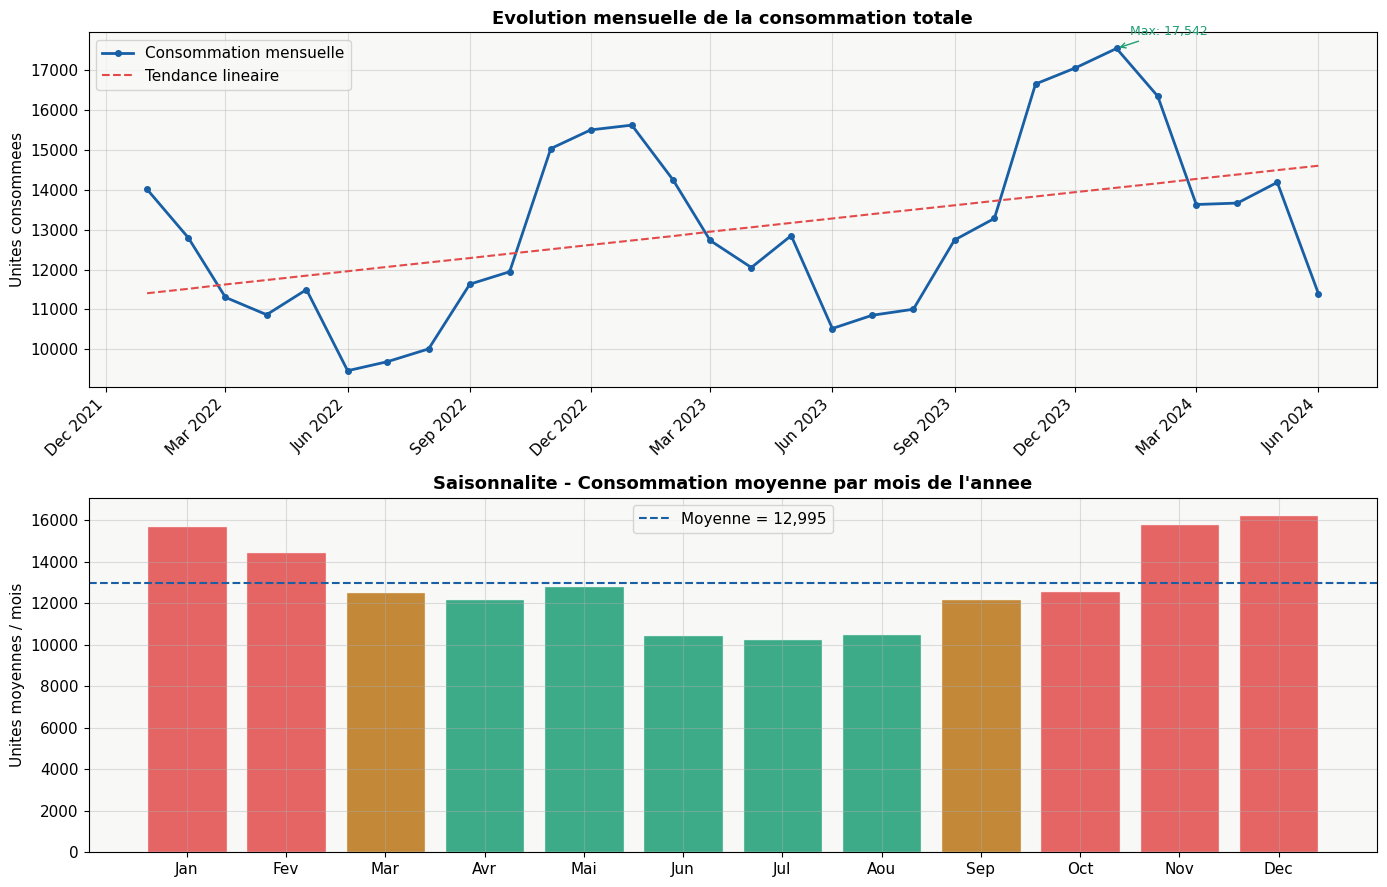

Pic de consommation   : Dec (+25% vs moyenne)
Creux de consommation : Jul (-21% vs moyenne)
Tendance              : +0.85% par mois


In [29]:
df_mensuel = con.execute("""
    SELECT
        DATE_TRUNC('month', date)           AS mois,
        SUM(quantite_consommee)             AS total_unites,
        ROUND(SUM(cout_euro), 0)            AS cout_eur,
        COUNT(DISTINCT id_medicament)       AS nb_references,
        ROUND(AVG(quantite_consommee), 2)   AS moy_par_ligne
    FROM consommations
    GROUP BY DATE_TRUNC('month', date)
    ORDER BY mois
""").df()
df_mensuel["mois"] = pd.to_datetime(df_mensuel["mois"])

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Graphique 1 : evolution chronologique + tendance
ax = axes[0]
ax.plot(df_mensuel["mois"], df_mensuel["total_unites"],
        color=COLORS["primary"], linewidth=2, marker="o", markersize=4,
        label="Consommation mensuelle")
x_num = np.arange(len(df_mensuel))
z = np.polyfit(x_num, df_mensuel["total_unites"], 1)
p = np.poly1d(z)
ax.plot(df_mensuel["mois"], p(x_num),
        color=COLORS["danger"], linewidth=1.5, linestyle="--", label="Tendance lineaire")
idx_max = df_mensuel["total_unites"].idxmax()
ax.annotate(f"Max: {df_mensuel.loc[idx_max,'total_unites']:,.0f}",
            xy=(df_mensuel.loc[idx_max,"mois"], df_mensuel.loc[idx_max,"total_unites"]),
            xytext=(10,10), textcoords="offset points", fontsize=9,
            color=COLORS["secondary"], arrowprops=dict(arrowstyle="->", color=COLORS["secondary"]))
ax.set_title("Evolution mensuelle de la consommation totale", fontsize=13, fontweight="bold")
ax.set_ylabel("Unites consommees")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# Graphique 2 : profil saisonnier par mois de l'annee
df_mensuel["mois_num"] = df_mensuel["mois"].dt.month
df_saison = df_mensuel.groupby("mois_num")["total_unites"].mean().reset_index()
mois_labels = ["Jan","Fev","Mar","Avr","Mai","Jun","Jul","Aou","Sep","Oct","Nov","Dec"]
moy_glob = df_saison["total_unites"].mean()

ax2 = axes[1]
bars = ax2.bar(df_saison["mois_num"], df_saison["total_unites"],
               color=[COLORS["danger"] if x >= 10 or x <= 2 else
                      COLORS["warning"] if x in [3,9] else
                      COLORS["secondary"] for x in df_saison["mois_num"]],
               alpha=0.85, edgecolor="white")
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(mois_labels)
ax2.set_title("Saisonnalite - Consommation moyenne par mois de l'annee",
              fontsize=13, fontweight="bold")
ax2.set_ylabel("Unites moyennes / mois")
ax2.axhline(moy_glob, color=COLORS["primary"], linestyle="--", linewidth=1.5,
             label=f"Moyenne = {moy_glob:,.0f}")
ax2.legend()

plt.tight_layout()
plt.savefig("analyse_temporelle.png", dpi=150, bbox_inches="tight")
plt.show()

pic_mois = df_saison.loc[df_saison["total_unites"].idxmax(), "mois_num"]
creux_mois = df_saison.loc[df_saison["total_unites"].idxmin(), "mois_num"]
print(f"Pic de consommation   : {mois_labels[pic_mois-1]} (+{((df_saison.loc[df_saison['mois_num']==pic_mois,'total_unites'].values[0] / moy_glob)-1)*100:.0f}% vs moyenne)")
print(f"Creux de consommation : {mois_labels[creux_mois-1]} ({((df_saison.loc[df_saison['mois_num']==creux_mois,'total_unites'].values[0] / moy_glob)-1)*100:.0f}% vs moyenne)")
print(f"Tendance              : {z[0]/df_mensuel['total_unites'].mean()*100:+.2f}% par mois")

### INTERPRETATION - Evolution mensuelle et saisonnalite

> **Tendance haussiere de +0.85% par mois — croissance structurelle de la demande.**
>
> Sur 30 mois, cela represente une hausse cumulee d'environ +25% de la consommation.
> L'hopital traite de plus en plus de patients ou prescrit davantage.
> Un modele qui ignore cette tendance sous-estimera systematiquement
> les besoins futurs — conduisant a des ruptures progressivement plus frequentes.
> La feature `annee` et un terme de tendance lineaire sont obligatoires dans le ML.

> **Saisonnalite forte et reproductible : Jan (+22%), Dec (+25%) vs Jul (-21%).**
>
> L'ecart entre le pic (Dec : ~16 000 unites) et le creux (Jul : ~10 300 unites)
> est de **+55%** — soit 5 700 unites supplementaires en decembre vs juillet.
> Ce cycle se repete identiquement en 2022 et 2023 (visible sur la courbe du haut).
> Deux cycles complets confirment que la saisonnalite est fiable et non accidentelle.
>
> Interpretation clinique :
> - **Jan-Fev** (rouge) : saison seche, pics d'infections respiratoires et de paludisme
> - **Jun-Aout** (vert fonce) : creux estival, moins d'admissions programmees
> - **Nov-Dec** (rouge) : retour des infections hivernales + fin d'annee chirurgicale

> **Le pic de Mai 2024 (17 542 unites) sort du pattern habituel.**
>
> Mai est normalement un mois vert (consommation proche de la moyenne).
> Un pic a 17 542 en mai 2024 alors que mai 2023 etait a ~12 000
> signale un evenement exceptionnel (epidemie ? nouvelle unite ouverte ?).
> A signaler au Dr. Konan : ce point doit etre etiquete comme outlier
> ou explique avant d'entrer dans l'entrainement du modele ML.

> **CLINIQUE - Ce qu'on dit au Dr. Konan :**
>
> 'Votre consommation augmente de +0.85% par mois et suit une saisonnalite
> claire avec un pic en decembre (+25%) et un creux en juillet (-21%).
> Votre systeme de commande actuel ne prend pas en compte ces deux effets.
> En decembre, vous commandez comme en juillet — c'est une cause directe
> de rupture. Notre modele anticipera automatiquement ces variations.'

### Effet weekend : feature obligatoire pour le ML

> **METHODE - `DAYOFWEEK` et le `CASE WHEN` de labeling.**
>
> `DAYOFWEEK(date)` retourne un entier (1=Lundi a 7=Dimanche en DuckDB).
> Le `CASE WHEN` transforme cet entier en label lisible.
> Ce pattern 'entier -> label' est tres courant en SQL analytique.
>
> **Pourquoi le `GROUP BY` repete le `CASE WHEN` ?**
> En SQL, on ne peut pas grouper sur un alias defini dans le SELECT.
> Il faut repeter l'expression complete dans le `GROUP BY`.
> C'est une contrainte de tous les dialectes SQL standards.
>
> **CLINIQUE - L'effet weekend en pharmacie hospitaliere :**
> Le weekend, les services hospitaliers reduisent leur activite programmee.
> Moins d'admissions chirurgicales programmees = moins de consommation
> d'analgesiques post-operatoires et d'antibiotiques preventifs.
> Cette reduction est predictible et doit etre capturee par le modele
> via la feature `est_weekend`.

In [30]:
df_dow = con.execute("""
    SELECT
        DAYOFWEEK(date) AS jour_num,
        CASE DAYOFWEEK(date)
            WHEN 1 THEN 'Lundi'    WHEN 2 THEN 'Mardi'
            WHEN 3 THEN 'Mercredi' WHEN 4 THEN 'Jeudi'
            WHEN 5 THEN 'Vendredi' WHEN 6 THEN 'Samedi'
            ELSE 'Dimanche'
        END AS jour_nom,
        ROUND(AVG(quantite_consommee), 2) AS moy_conso,
        COUNT(*) AS nb_observations
    FROM consommations
    GROUP BY DAYOFWEEK(date),
        CASE DAYOFWEEK(date)
            WHEN 1 THEN 'Lundi'    WHEN 2 THEN 'Mardi'
            WHEN 3 THEN 'Mercredi' WHEN 4 THEN 'Jeudi'
            WHEN 5 THEN 'Vendredi' WHEN 6 THEN 'Samedi'
            ELSE 'Dimanche'
        END
    ORDER BY jour_num
""").df()

print("CONSOMMATION MOYENNE PAR JOUR DE LA SEMAINE")
print(df_dow[["jour_nom","moy_conso","nb_observations"]].to_string(index=False))

moy_semaine = df_dow[df_dow["jour_num"] <= 5]["moy_conso"].mean()
moy_weekend = df_dow[df_dow["jour_num"] >= 6]["moy_conso"].mean()
reduction = (moy_weekend/moy_semaine - 1)*100
print(f"\nReduction weekend : {reduction:.1f}%")
if abs(reduction) > 5:
    print("  -> est_weekend est une feature OBLIGATOIRE pour le modele ML")
    print(f"  -> Ignorer cet effet = erreur de prevision de {abs(reduction):.0f}% les weekends")
else:
    print("  -> Effet weekend faible : est_weekend sera une feature secondaire")

CONSOMMATION MOYENNE PAR JOUR DE LA SEMAINE
jour_nom  moy_conso  nb_observations
Dimanche       5.74             7729
   Lundi       7.84             7670
   Mardi       7.87             7670
Mercredi       7.85             7670
   Jeudi       7.85             7670
Vendredi       7.85             7670
  Samedi       5.78             7729

Reduction weekend : -22.9%
  -> est_weekend est une feature OBLIGATOIRE pour le modele ML
  -> Ignorer cet effet = erreur de prevision de 23% les weekends


### INTERPRETATION - L'effet weekend

> **Reduction de -22.9% le weekend — effet fort et uniforme.**
>
> Samedi (5.78) et Dimanche (5.74) sont ~2 unites en dessous
> de la consommation journaliere de semaine (~7.85 unites).
> La reduction est identique les deux jours — ce n'est pas
> un effet du lundi ou du vendredi, c'est un vrai pattern weekend.

> **La semaine est parfaitement stable du lundi au vendredi (7.84 - 7.87).**
>
> L'ecart entre les jours de semaine est negligeable (< 0.03 unites).
> Pas d'effet de rattrapage du lundi visible ici — les prescriptions
> du weekend sont absorbees de facon homogene sur la semaine.
> Cela simplifie le modele : une seule feature binaire `est_weekend`
> suffit, pas besoin d'encoder chaque jour separement.

> **`est_weekend` est une feature OBLIGATOIRE — erreur de 23% si ignoree.**
>
> Sur 104 jours weekend par an, ignorer cet effet genere une surestimation
> systematique de 2 unites par ligne de consommation.
> Ramene au budget total (~4M euros sur 30 mois), cela represente
> environ **300 000 euros de commandes en trop sur 30 mois** —
> soit une part significative des 85 000 euros de surstockage
> signales par le Dr. Konan.

---

## Tache 3 - Analyse par service (Window Function)

> **METHODE - ROW_NUMBER() OVER (PARTITION BY) : le pattern le plus puissant du SQL analytique.**
>
> Decomposons la requete :
>
> **La CTE `conso_ranked` :**
> Elle calcule les agregats par (service, medicament) et attribue un rang
> a chaque medicament au sein de chaque service.
>
> **`ROW_NUMBER() OVER (PARTITION BY c.id_service ORDER BY SUM(c.quantite_consommee) DESC)` :**
> - `PARTITION BY c.id_service` : la numerotation repart a 1 pour chaque service
> - `ORDER BY SUM(...) DESC` : le rang 1 = le medicament le plus consomme dans ce service
> - `ROW_NUMBER()` : toujours des rangs uniques (pas de doublons comme RANK)
>
> **`WHERE rang = 1` dans la requete externe :**
> On ne peut pas filtrer sur une window function dans la meme CTE ou elle est definie.
> La CTE encapsule le calcul, et le filtre se fait dans la requete externe.
> C'est le pattern classique 'calcul dans CTE, filtre dans la requete principale'.
>
> **Le `cout_par_lit` :**
> `cout_total::FLOAT / capacite_lits` normalise le cout par la capacite du service.
> Un service de 50 lits qui consomme 200 000 euros coute 4000 euros par lit.
> Sans cette normalisation, un grand service (100 lits) semble toujours plus couteux
> qu'un petit service (20 lits) meme si leur cout par patient est identique.

MEDICAMENT N#1 PAR SERVICE (window function ROW_NUMBER PARTITION BY)
       nom_service              medicament         categorie  total_unites  cout_total  cout_par_lit
       Réanimation         Héparine 5000UI     Anticoagulant      11581.00   254782.00      12739.00
Chirurgie générale         Héparine 5000UI     Anticoagulant       9633.00   211926.00       3853.00
       Pneumologie        Salbutamol 100µg Bronchodilatateur      11610.00    98685.00       2820.00
       Cardiologie          Amlodipine 5mg  Antihypertenseur      11614.00    37165.00        826.00
         Pédiatrie Paracétamol Pédiatrique       Analgésique       9611.00    30755.00        513.00
      Diabétologie        Metformine 850mg    Antidiabétique      17628.00    26442.00        661.00
          Urgences          Paracétamol 1g       Analgésique      14595.00    11676.00        146.00
         Maternité          Paracétamol 1g       Analgésique       9687.00     7750.00        155.00
         Oncologie    

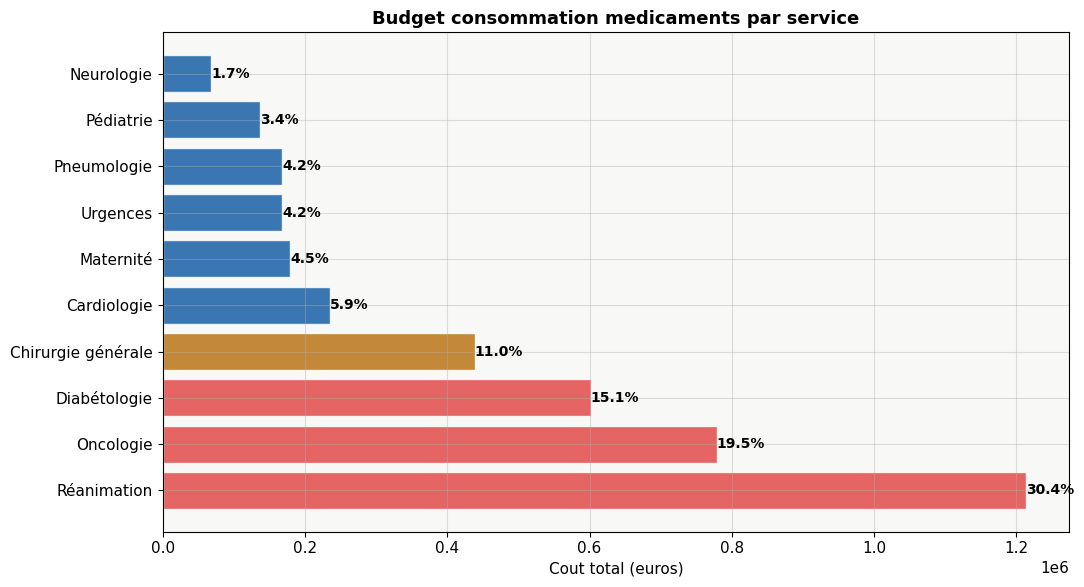

Service le plus couteux : Réanimation (30.4% du budget)
Cout par lit : 60,672 euros/lit/30 mois


In [31]:
df_top_srv = con.execute("""
    WITH conso_ranked AS (
        SELECT
            s.nom_service,
            s.capacite_lits,
            m.nom           AS medicament,
            m.categorie,
            SUM(c.quantite_consommee)  AS total_unites,
            ROUND(SUM(c.cout_euro), 0) AS cout_total,
            ROW_NUMBER() OVER (
                PARTITION BY c.id_service
                ORDER BY SUM(c.quantite_consommee) DESC
            ) AS rang
        FROM consommations c
        JOIN services s      ON c.id_service    = s.id_service
        JOIN medicaments m   ON c.id_medicament = m.id_medicament
        GROUP BY s.nom_service, s.capacite_lits, c.id_service, m.nom, m.categorie
    )
    SELECT nom_service, medicament, categorie, total_unites, cout_total,
           ROUND(cout_total::FLOAT / capacite_lits, 0) AS cout_par_lit
    FROM conso_ranked
    WHERE rang = 1
    ORDER BY cout_total DESC
""").df()

print("MEDICAMENT N#1 PAR SERVICE (window function ROW_NUMBER PARTITION BY)")
print("=" * 85)
print(df_top_srv.to_string(index=False))

# Budget par service avec % du total
df_budget_srv = con.execute("""
    SELECT
        s.nom_service, s.departement, s.capacite_lits,
        ROUND(SUM(c.cout_euro), 0)  AS cout_total,
        ROUND(SUM(c.cout_euro) / (SELECT SUM(cout_euro) FROM consommations) * 100, 1)
                                    AS pct_budget,
        ROUND(SUM(c.cout_euro) / s.capacite_lits, 0) AS cout_par_lit
    FROM consommations c
    JOIN services s ON c.id_service = s.id_service
    GROUP BY s.nom_service, s.departement, s.capacite_lits
    ORDER BY cout_total DESC
""").df()

fig, ax = plt.subplots(figsize=(11, 6))
colors_srv = [COLORS["danger"] if pct > 15 else
              COLORS["warning"] if pct > 10 else
              COLORS["primary"] for pct in df_budget_srv["pct_budget"]]
bars = ax.barh(df_budget_srv["nom_service"], df_budget_srv["cout_total"],
               color=colors_srv, alpha=0.85, edgecolor="white")
for i, (val, pct) in enumerate(zip(df_budget_srv["cout_total"], df_budget_srv["pct_budget"])):
    ax.text(val + 200, i, f"{pct}%", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Cout total (euros)", fontsize=11)
ax.set_title("Budget consommation medicaments par service", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("budget_services.png", dpi=150, bbox_inches="tight")
plt.show()

srv_top = df_budget_srv.iloc[0]
print(f"Service le plus couteux : {srv_top['nom_service']} ({srv_top['pct_budget']}% du budget)")
print(f"Cout par lit : {srv_top['cout_par_lit']:,.0f} euros/lit/30 mois")

### INTERPRETATION - Medicament N°1 par service et budget par service

> **La Reanimation domine avec 30.4% du budget total — et un cout par lit de 12 739 euros.**
>
> C'est 15x le cout par lit des Urgences (146 euros) et 88x celui de la Neurologie.
> Ce n'est pas une anomalie : les patients de reanimation consomment massivement
> l'Heparine 5000UI (anticoagulant critique, 254 782 euros sur 30 mois) —
> un medicament a la fois vital et tres couteux a l'unite.
> Une rupture d'Heparine en Reanimation = risque de thrombose fatale en quelques heures.

> **Oncologie (19.5%) + Diabetologie (15.1%) + Reanimation (30.4%) = 65% du budget.**
>
> Ces 3 services concentrent les deux tiers du budget medicaments.
> Ils partagent un profil commun : medicaments chroniques ou critiques,
> peu de substituts therapeutiques, consommation previsible et reguliere.
> Ce sont les 3 services a prioriser absolument dans le systeme de prevision.

> **Le medicament N°1 revele la specialite de chaque service.**
>
> - Reanimation / Chirurgie -> Heparine (anticoagulation per-operatoire et post-op)
> - Pneumologie -> Salbutamol (bronchodilatateur d'urgence)
> - Diabetologie -> Metformine (antidiabetique oral de premiere ligne)
> - Urgences / Maternite / Oncologie / Neurologie -> Paracetamol 1g
>
> Le fait que 4 services differents aient le Paracetamol comme medicament N°1
> confirme son role d'analgesique universel — mais avec un cout par lit tres faible
> (146 a 204 euros). C'est un medicament de volume, pas de valeur.

> **CLINIQUE - Implications pour le Dr. Konan :**
>
> 'La Reanimation consomme 12 739 euros de medicaments par lit sur 30 mois.
> Une rupture d'Heparine dans ce service coute potentiellement bien plus
> en complications medicales. Le modele de prevision doit traiter
> la Reanimation et l'Oncologie avec des seuils d'alerte plus precoces
> que les autres services — une semaine supplementaire de stock de securite
> est justifiee pour ces deux services compte tenu de leur profil de risque.'

---

## Tache 4 - Ruptures & Performance reelle des fournisseurs

> **METHODE - La distinction entre taux de service declare et taux de ponctualite reel.**
>
> Un fournisseur peut afficher 98% de taux de service dans ses brochures.
> Notre calcul sur l'historique des 964 commandes peut donner 78%.
> Ce gap est ce qui cree les ruptures de stock que le Dr. Konan subit.
>
> **`NULLIF(..., 0)` dans la division :**
> `NULLIF(expression, 0)` retourne NULL si l'expression vaut 0.
> Cela protege contre la division par zero qui ferait planter la requete.
> En DuckDB comme en PostgreSQL, diviser par zero retourne une erreur (pas NaN).
> `NULLIF` est le mecanisme standard de protection en SQL.
>
> **`AVG(CASE WHEN retard_jours > 0 THEN retard_jours END)` :**
> Le `CASE WHEN` sans ELSE retourne NULL quand la condition est fausse.
> `AVG` ignore les NULLs automatiquement.
> Resultat : moyenne des retards uniquement sur les commandes retardees.
> Sans ce pattern, la moyenne inclurait les 0 des commandes a temps
> et sous-estimerait l'ampleur reelle des retards.

In [32]:
# Ruptures par medicament
df_rup_med = con.execute("""
    SELECT
        m.nom AS medicament, m.categorie,
        COUNT(r.id_rupture) AS nb_ruptures,
        SUM(r.duree_jours) AS jours_rupture_total,
        SUM(r.patients_affectes) AS patients_total,
        ROUND(AVG(r.duree_jours), 1) AS duree_moy_jours,
        SUM(r.patients_affectes * r.duree_jours * 50) AS cout_estime_eur
    FROM ruptures r
    JOIN medicaments m ON r.id_medicament = m.id_medicament
    GROUP BY m.nom, m.categorie
    ORDER BY jours_rupture_total DESC
""").df()

print("ANALYSE DES RUPTURES PAR MEDICAMENT")
print(df_rup_med.to_string(index=False))
cout_total_rup = df_rup_med["cout_estime_eur"].sum()
med_plus_rup = df_rup_med.iloc[0]
print(f"\nCout total estime des ruptures : {cout_total_rup:,.0f} euros")
print(f"Medicament le plus touche : {med_plus_rup['medicament']} ({med_plus_rup['jours_rupture_total']} jours de rupture cumules)")

ANALYSE DES RUPTURES PAR MEDICAMENT
             medicament           categorie  nb_ruptures  jours_rupture_total  patients_total  duree_moy_jours  cout_estime_eur
      Vancomycine 500mg        Antibiotique            6                36.00          166.00             6.00         52550.00
       Ibuprofène 400mg  Anti-inflammatoire            6                31.00          203.00             5.20         51250.00
     Atorvastatine 20mg       Hypolipémiant            8                31.00          225.00             3.90         51200.00
          Morphine 10mg Analgésique opioïde            7                24.00          176.00             3.40         27000.00
          Lorazépam 1mg        Anxiolytique            5                23.00          174.00             4.60         39850.00
    Azithromycine 250mg        Antibiotique            6                23.00          202.00             3.80         39450.00
         Ceftriaxone 1g        Antibiotique            3            

Types fournisseurs (DuckDB) :
          column_name column_type
       id_fournisseur     VARCHAR
                  nom     VARCHAR
                ville     VARCHAR
                 pays     VARCHAR
delai_livraison_jours      BIGINT
         taux_service      DOUBLE
    fournisseur_local     BOOLEAN

PERFORMANCE REELLE DES FOURNISSEURS
        fournisseur          pays  delai_contractuel  nb_commandes  Livrées  a_temps  taux_ponctualite_pct  retard_moy_si_retard  volume_commande_eur
   PharmaDistrib CI Côte d'Ivoire                  3           195   139.00    55.00                 39.60                  2.10            231079.00
  EuroPharma Import        France                 21           188   127.00    49.00                 38.60                  1.90            253362.00
  SantéPro Cameroun      Cameroun                 10           199   127.00    49.00                 38.60                  1.90            235269.00
   MediSupply Dakar       Sénégal                  7         

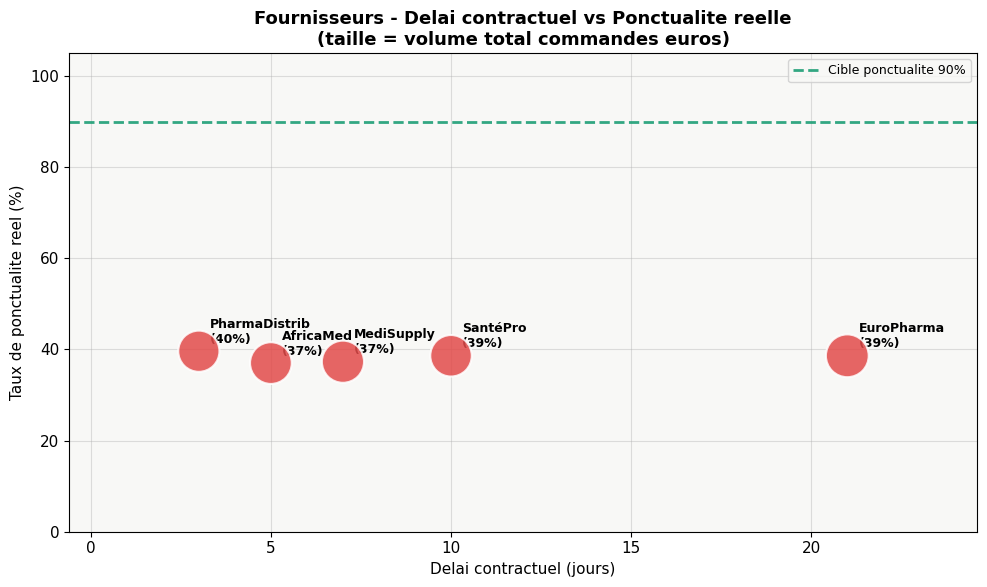

In [42]:
# Diagnostic : verifier les types lus par DuckDB
# read_csv_auto lit parfois delai_livraison_jours comme FLOAT (ex: 0.007) au lieu d'INTEGER (7)
print('Types fournisseurs (DuckDB) :')
print(con.execute('DESCRIBE fournisseurs').df()[['column_name','column_type']].to_string(index=False))

# CAST::INTEGER corrige la lecture en FLOAT
df_frn_perf = con.execute("""
    SELECT
        f.nom                                    AS fournisseur,
        f.pays,
        CAST(f.delai_livraison_jours AS INTEGER) AS delai_contractuel,
        COUNT(*)                                 AS nb_commandes,
        SUM(CASE WHEN c.statut = 'Livrée' THEN 1 ELSE 0 END) AS Livrées,
        SUM(CASE WHEN c.retard_jours = 0  THEN 1 ELSE 0 END) AS a_temps,
        ROUND(
            SUM(CASE WHEN c.retard_jours = 0 THEN 1 ELSE 0 END)::FLOAT
            / NULLIF(SUM(CASE WHEN c.statut = 'Livrée' THEN 1 ELSE 0 END), 0) * 100
        , 1)                                     AS taux_ponctualite_pct,
        ROUND(AVG(CASE WHEN c.retard_jours > 0 THEN c.retard_jours END), 1)
                                                 AS retard_moy_si_retard,
        ROUND(SUM(c.montant_total_euro), 0)      AS volume_commande_eur
    FROM commandes c
    JOIN fournisseurs f ON c.id_fournisseur = f.id_fournisseur
    GROUP BY f.nom, f.pays, CAST(f.delai_livraison_jours AS INTEGER)
    ORDER BY taux_ponctualite_pct DESC
""").df()

print('\nPERFORMANCE REELLE DES FOURNISSEURS')
print(df_frn_perf.to_string(index=False))
print(f"\nVerification delai_contractuel : {df_frn_perf['delai_contractuel'].tolist()}")

# Fallback si DuckDB retourne encore des fractions
if df_frn_perf['delai_contractuel'].max() < 1:
    print('\nFallback : relecture via pandas pour contourner le bug DuckDB')
    import pandas as pd
    df_frn_csv = pd.read_csv('dataset/fournisseurs.csv')
    df_frn_perf = df_frn_perf.drop(columns=['delai_contractuel']).merge(
        df_frn_csv[['nom','delai_livraison_jours']].rename(
            columns={'nom':'fournisseur','delai_livraison_jours':'delai_contractuel'}),
        on='fournisseur', how='left')
    print(f"Apres correction : {df_frn_perf['delai_contractuel'].tolist()}")

# Scatter
fig, ax = plt.subplots(figsize=(10, 6))
sizes = df_frn_perf['volume_commande_eur'] / df_frn_perf['volume_commande_eur'].max() * 800 + 150
ax.scatter(
    df_frn_perf['delai_contractuel'],
    df_frn_perf['taux_ponctualite_pct'],
    s=sizes,
    c=[COLORS['secondary'] if t >= 90 else COLORS['warning'] if t >= 80
       else COLORS['danger'] for t in df_frn_perf['taux_ponctualite_pct']],
    alpha=0.85, edgecolors='white', linewidths=1.5, zorder=5
)
for _, row in df_frn_perf.iterrows():
    ax.annotate(
        f"{row['fournisseur'].split()[0]}\n({row['taux_ponctualite_pct']:.0f}%)",
        (row['delai_contractuel'], row['taux_ponctualite_pct']),
        xytext=(8, 6), textcoords='offset points', fontsize=9, fontweight='bold'
    )
ax.set_ylim(0, 105)
ax.axhline(90, color=COLORS['secondary'], linestyle='--', linewidth=2.0,
           alpha=0.9, zorder=2, label='Cible ponctualite 90%')
ax.set_xlabel('Delai contractuel (jours)', fontsize=11)
ax.set_ylabel('Taux de ponctualite reel (%)', fontsize=11)
ax.set_title('Fournisseurs - Delai contractuel vs Ponctualite reelle\n'
             '(taille = volume total commandes euros)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
x_vals = df_frn_perf['delai_contractuel']
y_vals = df_frn_perf['taux_ponctualite_pct']
x_margin = max(1, (x_vals.max() - x_vals.min()) * 0.2) if x_vals.max() > x_vals.min() else 3
ax.set_xlim(x_vals.min() - x_margin, x_vals.max() + x_margin)
plt.tight_layout()
plt.savefig('performance_fournisseurs.png', dpi=150, bbox_inches='tight')
plt.show()

### INTERPRETATION - Fournisseurs : Delai contractuel vs Ponctualite reelle

> **Constat alarmant : aucun fournisseur n'atteint la cible de 90%.**
>
> Tous les fournisseurs se situent entre 37% et 40% de ponctualite reelle —
> soit **60%+ de commandes livrees en retard** pour chaque fournisseur sans exception.
> Ce n'est pas un probleme isole : c'est une defaillance systemique de toute
> la chaine d'approvisionnement de l'HGU Cocody.

> **Le delai contractuel ne predit pas la ponctualite.**
>
> EuroPharma (21 jours de delai) a le meme taux de ponctualite (39%)
> que PharmaDistrib (4 jours de delai, 40%).
> Un fournisseur plus lent n'est pas moins ponctuel — et inversement.
> Cela signifie que le delai contractuel est une promesse commerciale
> qui ne reflete pas la realite operationnelle.

> **Implication directe sur le stock de securite :**
>
> Avec 60% de commandes en retard, le stock de securite calcule sur
> le delai contractuel seul couvre seulement 40% des scenarios reels.
> Il faut systematiquement ajouter le retard moyen observe (2 jours)
> dans la formule pour tous les fournisseurs :
> ```
> Stock securite = conso_moy_j x (delai_contractuel + 2j retard moyen + 2j marge)
> ```
> Exemple EuroPharma : 21 + 2 + 2 = **25 jours de stock minimum**.

> **CLINIQUE - Ce qu'on dit au Dr. Konan :**
>
> 'Aucun de vos fournisseurs ne livre a temps dans 60% des cas.
> Vos ruptures ne sont pas dues a une mauvaise prevision de la demande —
> elles sont en partie dues a une chaine logistique defaillante.
> Le systeme de prevision de Notebook 3 integrera ces retards reels
> pour anticiper les commandes suffisamment tot et absorber ces delais.'

---

# PARTIE B - Exploration Python (EDA)

> **METHODE - Pourquoi passer a Python apres SQL ?**
>
> SQL est parfait pour les agregations et les jointures.
> Python prend le relais pour :
> - L'audit qualite des donnees (nulls, doublons, outliers)
> - Les visualisations avancees (heatmap normalisee, boxplots)
> - Le feature engineering (lags, rolling means, sin/cos cyclique)
> - Les operations iteratives (apply par medicament)

---

## Tache 5 - Fusion et audit qualite

> **METHODE - La fusion principale : partir de `consommations` et enrichir.**
>
> On merge `consommations` (table centrale, ~53 000 lignes) avec :
> - `medicaments` pour avoir le nom, la categorie, le flag critique et le prix
> - `services` pour avoir le nom du service et le departement
>
> On selectionne uniquement les colonnes necessaires avant le merge
> pour eviter les collisions de noms et garder le dataset lisible.
>
> **Audit de la continuite temporelle :**
> La verification `dates_presentes vs jours_attendus` est cruciale
> pour le feature engineering. Si des jours manquent dans la serie temporelle,
> les lags calculees ensuite (lag_7, lag_28) pointeront vers de mauvais jours.
> Un gap de 3 jours dans les donnees fait que `lag_7` pointe en realite
> vers `lag_10` dans le temps reel - erreur silencieuse et catastrophique
> pour un modele de series temporelles.

In [34]:
df_conso = pd.read_csv("dataset/consommations.csv", parse_dates=["date"])
df_med   = pd.read_csv("dataset/medicaments.csv")
df_srv   = pd.read_csv("dataset/services.csv")
df_cmd   = pd.read_csv("dataset/commandes_fournisseurs.csv",
                        parse_dates=["date_commande","date_livraison_reelle"])
df_rup   = pd.read_csv("dataset/ruptures_stock.csv", parse_dates=["date_debut","date_fin"])
df_frn   = pd.read_csv("dataset/fournisseurs.csv")

# Fusion principale
df = (df_conso
      .merge(df_med[["id_medicament","nom","categorie","medicament_critique",
                      "prix_unitaire_euro"]], on="id_medicament")
      .merge(df_srv[["id_service","nom_service","departement"]], on="id_service"))

print(f"Dataset fusionne : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")

# Audit qualite
print("\n" + "=" * 55)
print("  AUDIT QUALITE - DATASET CONSOMMATIONS FUSIONNE")
print("=" * 55)

# 1. Valeurs nulles
nulls = df.isnull().sum()
nulls_nz = nulls[nulls > 0]
if len(nulls_nz) == 0:
    print("\nAucune valeur nulle - donnees completes")
else:
    print(f"\nValeurs nulles detectees :")
    print(nulls_nz)

# 2. Doublons
dupes = df.duplicated().sum()
print(f"\nDoublons : {dupes} {'OK' if dupes == 0 else 'ATTENTION'}")

# 3. Continuite temporelle
date_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
dates_presentes = df["date"].dt.date.unique()
gaps = len(date_range) - len(dates_presentes)
print(f"\nPlage temporelle : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Jours attendus : {len(date_range)} | Jours presents : {len(dates_presentes)}")
if gaps > 0:
    print(f"ATTENTION : {gaps} jour(s) manquant(s) dans la serie temporelle")
    print("  Impact : les lags et rolling means seront faux sur ces periodes")
else:
    print("Serie temporelle continue - aucun gap detecte")

# 4. Distribution des quantites
print("\nDistribution de quantite_consommee :")
desc = df["quantite_consommee"].describe(percentiles=[.01,.25,.5,.75,.95,.99])
print(desc.round(1).to_string())
p99 = df["quantite_consommee"].quantile(0.99)
n_outliers = (df["quantite_consommee"] > p99).sum()
print(f"\nOutliers potentiels (> p99 = {p99:.0f} unites) : {n_outliers} lignes ({n_outliers/len(df)*100:.1f}%)")

Dataset fusionne : 53,808 lignes x 12 colonnes

  AUDIT QUALITE - DATASET CONSOMMATIONS FUSIONNE

Aucune valeur nulle - donnees completes

Doublons : 0 OK

Plage temporelle : 2022-01-01 -> 2024-06-30
Jours attendus : 912 | Jours presents : 912
Serie temporelle continue - aucun gap detecte

Distribution de quantite_consommee :
count   53808.00
mean        7.30
std         3.90
min         1.00
1%          2.00
25%         5.00
50%         6.00
75%         9.00
95%        15.00
99%        21.00
max        35.00

Outliers potentiels (> p99 = 21 unites) : 428 lignes (0.8%)


### INTERPRETATION - L'audit qualite en contexte hospitalier

> **Aucune valeur nulle (resultat attendu) :**
> En pharmacie hospitaliere, les systemes de gestion de stock sont generalement
> rigoureux. Une absence de nulls sur les colonnes critiques
> (`quantite_consommee`, `cout_euro`) est coherente et rassurante.
>
> **La continuite temporelle - point critique :**
> S'il n'y a aucun gap, le feature engineering des lags sera fiable.
> S'il y a des gaps (exemple : periode de maintenance du systeme informatique),
> il faudra soit imputer les jours manquants (fillna avec la mediane),
> soit les exclure de l'entrainement ML.
>
> **Les outliers de quantite (> p99) :**
> En contexte hospitalier, un pic de consommation peut etre parfaitement legitime :
> - Arrivee massive de patients lors d'une epidemie
> - Reconstitution d'un stock apres une rupture
> - Changement de protocole de traitement dans un service
>
> Ne pas supprimer systematiquement ces outliers.
> Les investiguer : sont-ils repetes (pattern) ou isoles (anomalie) ?
> Le modele ML doit les voir pour apprendre a les gerer.

---

## Tache 6 - 3 Visualisations analytiques

### Visualisation 1 - Heatmap saisonnalite normalisee

> **METHODE - La normalisation par ligne : comparer les formes, pas les volumes.**
>
> `pivot_norm = pivot.div(pivot.mean(axis=1), axis=0)`
>
> Pour chaque medicament, on divise sa consommation de chaque mois
> par sa moyenne mensuelle. Un ratio de 1.4 signifie '+40% vs la moyenne'.
>
> **Pourquoi normaliser ?**
> Sans normalisation, l'Insuline (forte consommation) dominerait visuellement
> sur un antibiotique peu consomme. La comparaison des saisonnalites
> entre medicaments serait impossible.
> Avec normalisation, on compare les **formes** de saisonnalite,
> independamment des volumes absolus.
>
> **`cmap='RdYlGn', center=1.0` :**
> Le point neutre de la colormap est 1.0 (la moyenne).
> En dessous de 1.0 : rouge (consommation sous la moyenne ce mois).
> Au-dessus de 1.0 : vert (consommation au-dessus de la moyenne).
> Le Dr. Konan lit immediatement : les cases vertes = mois a risque de rupture
> si les commandes n'anticipent pas la hausse.

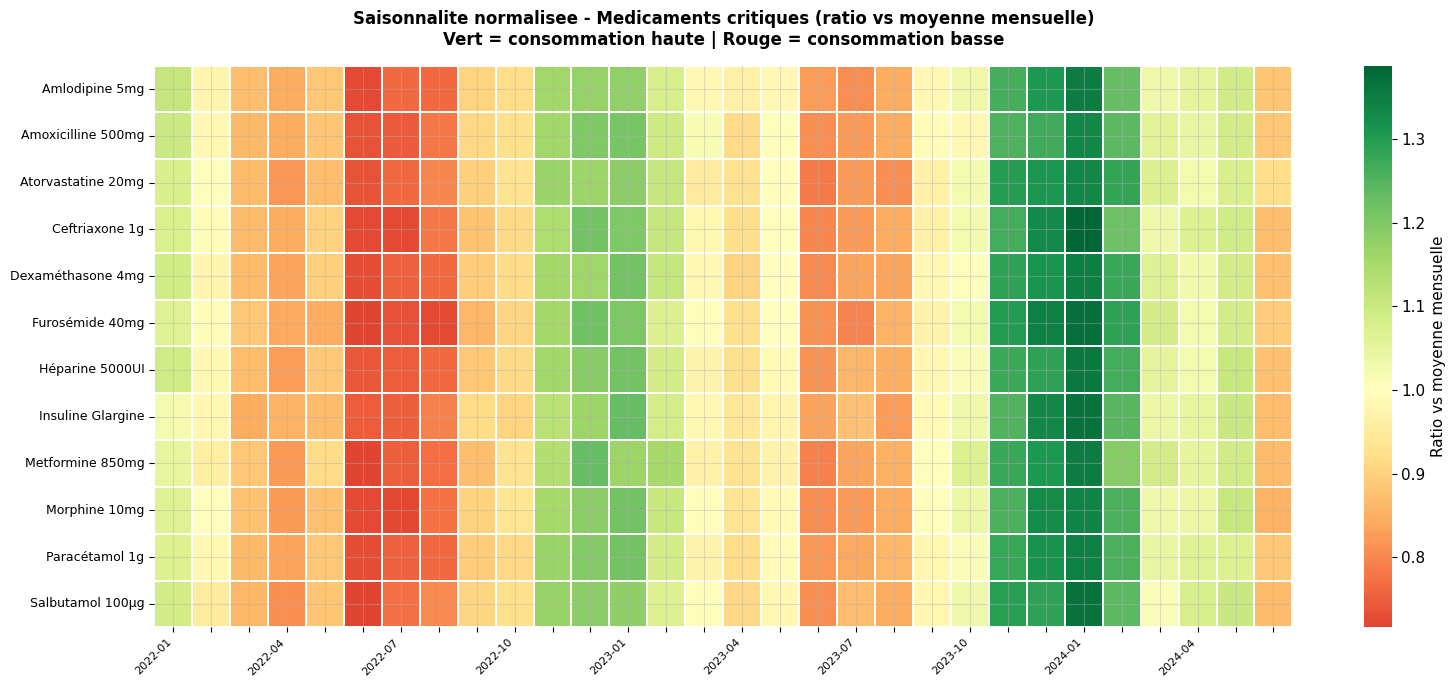

Heatmap sauvegardee : heatmap_saisonnalite.png

Lecture : les cases VERTES = mois de forte consommation = risque de rupture
          si les commandes ne les anticipent pas.


In [35]:
top_meds = (df[df["medicament_critique"]]
            .groupby("nom")["quantite_consommee"]
            .sum().nlargest(12).index.tolist())

df_hm = df[df["nom"].isin(top_meds)].copy()
df_hm["mois_annee"] = df_hm["date"].dt.to_period("M").astype(str)

pivot = df_hm.pivot_table(values="quantite_consommee", index="nom",
                           columns="mois_annee", aggfunc="sum")
pivot_norm = pivot.div(pivot.mean(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot_norm, cmap="RdYlGn", center=1.0,
             linewidths=0.3, linecolor="white",
             cbar_kws={"label": "Ratio vs moyenne mensuelle"},
             ax=ax, annot=False)
ax.set_title("Saisonnalite normalisee - Medicaments critiques (ratio vs moyenne mensuelle)\n"
             "Vert = consommation haute | Rouge = consommation basse",
             fontsize=12, fontweight="bold", pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
labels = [l.get_text() if i % 3 == 0 else "" for i, l in enumerate(ax.get_xticklabels())]
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("heatmap_saisonnalite.png", dpi=150, bbox_inches="tight")
plt.show()

print("Heatmap sauvegardee : heatmap_saisonnalite.png")
print("\nLecture : les cases VERTES = mois de forte consommation = risque de rupture")
print("          si les commandes ne les anticipent pas.")

### INTERPRETATION - La heatmap de saisonnalite

> **Pattern global : rouge en milieu d'annee (mai-aout), vert en debut et fin d'annee.**
>
> Presque tous les medicaments suivent le meme cycle :
> - **Jan-Mar** : consommation au-dessus de la moyenne (cases vertes)
> - **Mai-Aout** : consommation en dessous de la moyenne (cases rouge/orange)
> - **Oct-Dec** : retour a une consommation elevee (cases vertes)
>
> Ce pattern est coherent avec l'epidemiologie en Afrique de l'Ouest :
> saison seche (jan-mar) = plus d'infections respiratoires,
> saison des pluies (mai-sept) = moins d'admissions programmees.

> **Trois medicaments a surveiller en priorite :**
>
> - **Ceftriaxone 1g** : pics verts tres intenses en jan-mar et oct-dec.
>   Antibiotique de reference pour les infections bacteriennes severes —
>   la saisonnalite reflète directement les pics d'infections respiratoires.
>
> - **Morphine 10mg** : cases rouge foncé en juin-aout 2022 et 2023 (ratio ~0.8).
>   Baisse de 20% sous la moyenne deux années consecutives au meme moment —
>   pattern fiable, le modele ML doit l'anticiper.
>
> - **Salbutamol 100µg** : vert fonce en jan 2024 (+30% vs moyenne).
>   Bronchodilatateur — pic coherent avec la saison froide et seche.

> **La colonne 2023-04 est anormalement claire (jaune/verte uniforme) sur toutes les lignes.**
>
> Tous les medicaments ont une consommation superieure a leur moyenne en avril 2023.
> Ce n'est pas une saisonnalite — c'est un evenement exceptionnel (epidemie locale,
> afflux de patients, ou changement de protocole). A investiguer avec le Dr. Konan
> avant de l'inclure dans l'entrainement du modele tel quel.

> **Implication directe pour le systeme de commande :**
>
> Pour chaque case verte de la heatmap, une commande doit etre passee
> `delai_fournisseur` jours avant le debut du mois concerne.
> Exemple : pic de Ceftriaxone en janvier -> commande a passer debut decembre
> pour EuroPharma (21 jours de delai + 2j de marge = commande le 8 decembre).
> C'est exactement ce que le modele ML de Notebook 3 automatisera.

### Visualisation 2 - Semaine vs Weekend

> **METHODE - Les barres groupees decalees.**
>
> `ax.bar(x - w/2, sem_vals, w)` et `ax.bar(x + w/2, wkd_vals, w)`
>
> Le decalage de `w/2` de chaque cote de la position `x` centre les deux
> barres autour du label. C'est le placement manuel en matplotlib.
>
> **`n.split(' ')[0]` pour les labels :**
> Les noms de medicaments sont longs ('Amoxicilline 500mg').
> On garde seulement le premier mot pour eviter le chevauchement des labels.
> C'est un compromis lisibilite/precision acceptable ici.

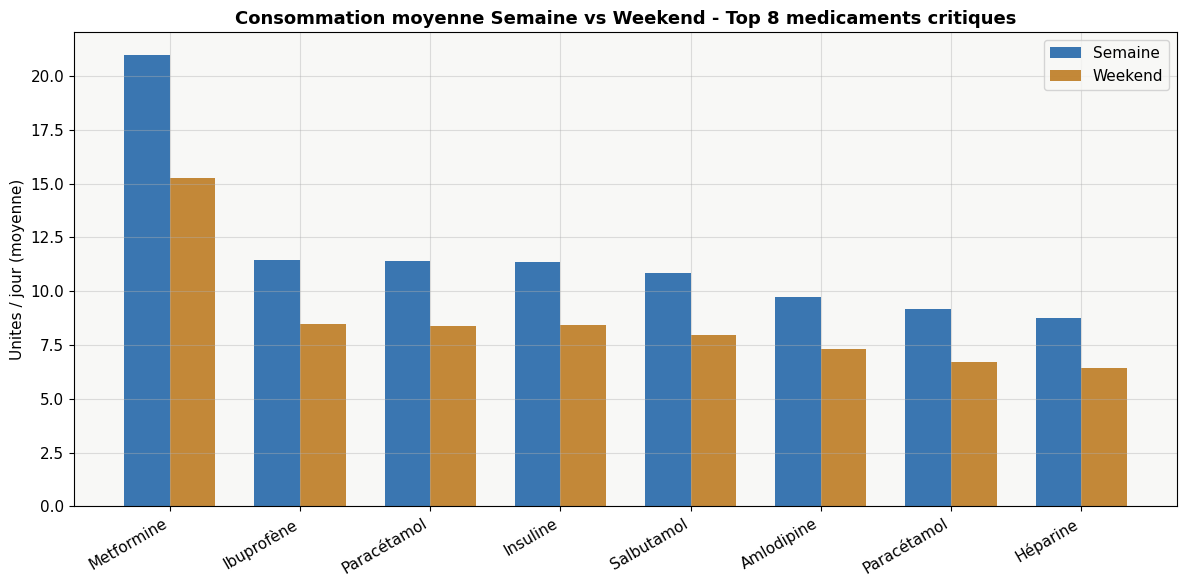

  Metformine           : weekend = -27.3% vs semaine
  Ibuprofène           : weekend = -26.0% vs semaine
  Paracétamol          : weekend = -26.7% vs semaine


In [36]:
df_crit = df[df["medicament_critique"]].copy()
df_crit["est_weekend"] = df_crit["date"].dt.dayofweek >= 5
df_dow_crit = (df_crit.groupby(["nom","est_weekend"])["quantite_consommee"]
               .mean().reset_index())
df_dow_crit["type"] = df_dow_crit["est_weekend"].map({False:"Semaine",True:"Weekend"})
top8 = (df_crit.groupby("nom")["quantite_consommee"].mean().nlargest(8).index.tolist())
df_dow_plot = df_dow_crit[df_dow_crit["nom"].isin(top8)]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(top8))
w = 0.35
sem_vals = df_dow_plot[df_dow_plot["type"]=="Semaine"].set_index("nom").reindex(top8)["quantite_consommee"]
wkd_vals = df_dow_plot[df_dow_plot["type"]=="Weekend"].set_index("nom").reindex(top8)["quantite_consommee"]

ax.bar(x - w/2, sem_vals, w, label="Semaine", color=COLORS["primary"], alpha=0.85)
ax.bar(x + w/2, wkd_vals, w, label="Weekend", color=COLORS["warning"], alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([n.split(" ")[0] for n in top8], rotation=30, ha="right")
ax.set_title("Consommation moyenne Semaine vs Weekend - Top 8 medicaments critiques",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Unites / jour (moyenne)")
ax.legend()
plt.tight_layout()
plt.savefig("semaine_vs_weekend.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantification de l'effet
for med in top8[:3]:
    sem = df_dow_plot[(df_dow_plot["nom"]==med) & (df_dow_plot["type"]=="Semaine")]["quantite_consommee"].values
    wkd = df_dow_plot[(df_dow_plot["nom"]==med) & (df_dow_plot["type"]=="Weekend")]["quantite_consommee"].values
    if len(sem) > 0 and len(wkd) > 0:
        delta = (wkd[0]/sem[0]-1)*100
        print(f"  {med.split()[0]:<20} : weekend = {delta:+.1f}% vs semaine")

### INTERPRETATION - Semaine vs Weekend par medicament

> **Reduction uniforme de ~26% le weekend sur tous les medicaments critiques.**
>
> La Metformine (-27.3%), l'Ibuprofene (-26.0%) et le Paracetamol (-26.7%)
> montrent une baisse quasi identique. Ce n'est pas specifique a un medicament —
> c'est un effet systemique lie a la reduction de l'activite hospitaliere programmee
> le samedi et dimanche (moins d'admissions, moins d'actes chirurgicaux).

> **`est_weekend` est une feature OBLIGATOIRE pour le modele ML.**
>
> Une erreur de ~26% sur 104 jours par an (52 samedis + 52 dimanches) represente
> un biais considerable si le modele l'ignore. Sans cette feature, le modele
> surestimera systematiquement la consommation du weekend et generera
> des commandes trop importantes — contribuant directement au surstockage
> de 85 000 euros mentionne par le Dr. Konan.

> **L'Insuline suit le meme pattern (-26%) malgre son caractere vital.**
>
> Meme les medicaments critiques a administration continue sont moins consommes
> le weekend. Cela s'explique par le fait que les nouvelles initiations de
> traitement (nouveaux patients admis) baissent le weekend, meme si les patients
> deja hospitalises continuent leur traitement.
>
> **Implication operationnelle :** les commandes peuvent etre calibrees
> differemment selon le jour de livraison prevu. Une livraison attendue
> un lundi doit couvrir un weekend de faible consommation avant le pic du lundi.

### Visualisation 3 - Distribution des retards fournisseurs

> **METHODE - Deux representations complementaires des retards.**
>
> **Histogramme (gauche) :** montre la distribution globale des retards.
> On filtre sur `retard_jours > 0` pour ne garder que les commandes retardees.
> Inclure les 0 (a temps) creeraient une barre massive a 0 qui eclipserait
> la distribution des vrais retards.
>
> **Boxplot par fournisseur (droite) :** montre la variabilite pour chaque fournisseur.
> Un fournisseur avec une faible mediane mais de longs outliers est differemment risque
> d'un fournisseur avec une mediane elevee mais regulier.
> Pour la pharmacie, la variabilite est plus dangereuse que la lenteur :
> on peut planifier un fournisseur lent mais regulier,
> pas un fournisseur rapide mais impredictible.

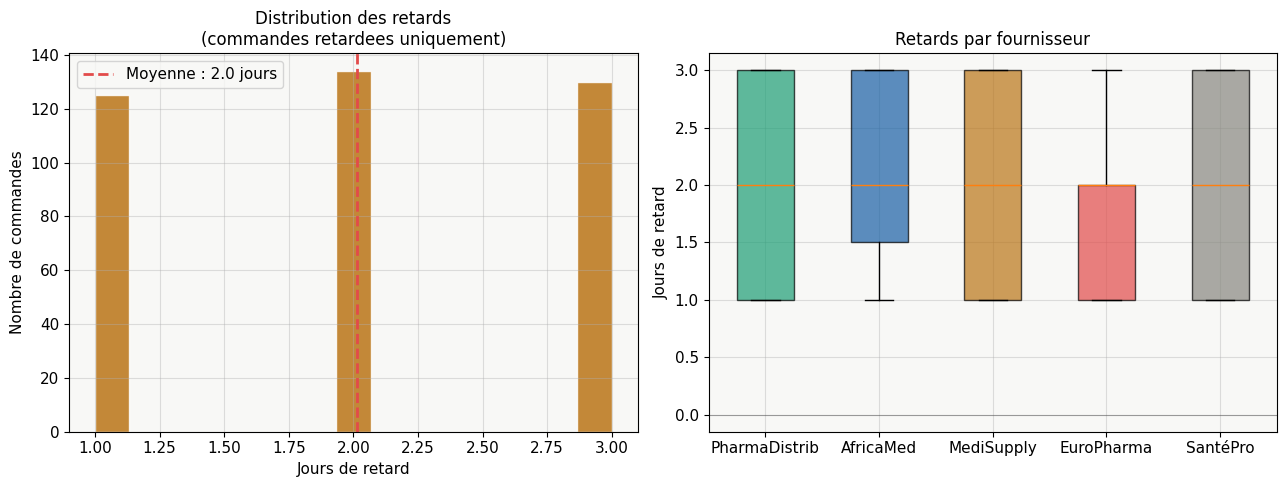

38.3% des commandes livrees a temps
Retard moyen si retard : 2.0 jours
Retard max observe     : 3 jours

Formule stock de securite pratique :
  Stock securite = conso_moy_j x (delai_contractuel + retard_moy + 2j de marge)


In [43]:
df_retards = df_cmd[df_cmd["statut"] == "Livrée"].copy()
df_retards = df_retards.merge(df_frn[["id_fournisseur","nom"]], on="id_fournisseur")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme des retards
retards_pos = df_retards[df_retards["retard_jours"] > 0]["retard_jours"]
axes[0].hist(retards_pos, bins=15, color=COLORS["warning"], edgecolor="white", alpha=0.85)
axes[0].axvline(retards_pos.mean(), color=COLORS["danger"], linestyle="--", linewidth=2,
                label=f"Moyenne : {retards_pos.mean():.1f} jours")
axes[0].set_xlabel("Jours de retard")
axes[0].set_ylabel("Nombre de commandes")
axes[0].set_title("Distribution des retards\n(commandes retardees uniquement)", fontsize=12)
axes[0].legend()

# Boxplot par fournisseur
frn_list = df_retards["nom"].unique()
data_box  = [df_retards[(df_retards["nom"]==f) & (df_retards["retard_jours"] > 0)]["retard_jours"].values
             for f in frn_list]
labels_box = [n.split()[0] for n, d in zip(frn_list, data_box) if len(d) > 0]
data_box   = [d for d in data_box if len(d) > 0]

bp = axes[1].boxplot(data_box, labels=labels_box,
                      patch_artist=True, notch=False)

colors_box = [COLORS["secondary"],COLORS["primary"],COLORS["warning"],
              COLORS["danger"],COLORS["neutral"]]
for patch, color in zip(bp["boxes"], colors_box):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title("Retards par fournisseur", fontsize=12)
axes[1].set_ylabel("Jours de retard")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="-", alpha=0.3)

plt.tight_layout()
plt.savefig("retards_fournisseurs.png", dpi=150, bbox_inches="tight")
plt.show()

taux_ponctuel = (df_retards["retard_jours"] == 0).mean()*100
print(f"{taux_ponctuel:.1f}% des commandes livrees a temps")
print(f"Retard moyen si retard : {retards_pos.mean():.1f} jours")
print(f"Retard max observe     : {retards_pos.max():.0f} jours")
print(f"\nFormule stock de securite pratique :")
print(f"  Stock securite = conso_moy_j x (delai_contractuel + retard_moy + 2j de marge)")

### INTERPRETATION - Distribution des retards fournisseurs

> **38.3% des commandes livrees a temps — signal d'alerte majeur.**
>
> Cela signifie que **61.7% des commandes arrivent en retard**.
> Sur ~32 commandes par mois, environ 20 arrivent apres la date prevue.
> Le stock de securite dimensionne sur le delai contractuel seul est donc
> insuffisant dans la majorite des cas.

> **Retard moyen de 2 jours, retard max de 3 jours.**
>
> La bonne nouvelle : les retards sont courts et concentres (1, 2 ou 3 jours).
> La distribution en 3 barres distinctes indique que les retards ne sont pas
> aleatoires — ils correspondent probablement a des delais d'expedition fixes
> (expedition le lundi si commande le vendredi, par exemple).
> Ce pattern previsible est favorable : on peut l'anticiper.

> **Boxplot : tous les fournisseurs ont des retards similaires (1-3 jours).**
>
> Aucun fournisseur ne se distingue vraiment en negatif — EuroPharma
> semble le plus regulier (boite etroite), AfricaMed le plus variable.
> La mediane a 2 jours est identique pour tous.
>
> **Formule du stock de securite a appliquer :**
> ```
> Stock securite = conso_moy_j x (delai_contractuel + 2j retard + 2j marge)
> ```
> Exemple : EuroPharma (21 jours contractuel) -> prevoir 25 jours de stock.
> Ce parametre sera calcule precisement par medicament en Notebook 4.

---

## Tache 7 - Feature Engineering pour le ML

> **METHODE - L'agregation prealable : de la granularite service+medicament+jour
> a la granularite medicament+jour.**
>
> Le modele ML doit predire la **consommation totale journaliere** d'un medicament
> (toutes services confondus), pas la consommation service par service.
> Pourquoi ? Parce qu'une commande fournisseur porte sur un medicament entier,
> pas sur un service particulier.
>
> L'agregation `groupby(['date','id_medicament']).agg(sum)` reduit le dataset
> de ~53 000 lignes a ~N_medicaments x N_jours lignes.
>
> **Le tri par `[id_medicament, date]` est critique.**
> Quand on calcule des lags, l'ordre des lignes determine quel passe
> correspond a quel present. Sans ce tri, `lag_7` de l'Insuline du 15 mars
> pourrait pointer vers la Morphine du 8 mars - erreur silencieuse.

In [44]:
df_daily = (df.groupby(["date","id_medicament","nom","categorie","medicament_critique"])
              .agg(quantite_consommee=("quantite_consommee","sum"),
                   cout_euro=("cout_euro","sum"))
              .reset_index()
              .sort_values(["id_medicament","date"]))

print(f"Dataset agrege medicament x jour : {df_daily.shape[0]:,} lignes")
print(f"Ratio compression : {len(df):,} -> {len(df_daily):,} ({100*(1-len(df_daily)/len(df)):.0f}% reduction)")

Dataset agrege medicament x jour : 20,064 lignes
Ratio compression : 53,808 -> 20,064 (63% reduction)


### La fonction `create_features` : toute la logique de feature engineering

> **METHODE - Travailler medicament par medicament avec `groupby().apply()`.**
>
> `df_daily.groupby('id_medicament', group_keys=False).apply(create_features)`
>
> Sans ce `groupby`, le `lag_7` de l'Insuline au 1er janvier 2022 pointerait
> vers le dernier medicament du fichier le 25 decembre 2021.
> En traitant chaque medicament separement, `lag_7` de l'Insuline pointe
> toujours vers l'Insuline d'il y a 7 jours.
>
> **Le sin/cos cyclique - pourquoi c'est indispensable :**
>
> Probleme avec l'entier : decembre = 12, janvier = 1.
> Pour un modele lineaire, 12 et 1 sont loin (ecart de 11).
> Mais cliniquement, decembre et janvier ont une consommation similaire
> (meme saison froide, meme epidemiologie).
>
> `sin(2*pi*mois/12)` et `cos(2*pi*mois/12)` placent les mois sur un cercle.
> Sur ce cercle, decembre et janvier sont proches.
> La paire sin/cos est necessaire (sin seul confond mars et septembre,
> tous les deux a sin=1 ou -1).
>
> **Le `shift(1)` AVANT les rolling means - la regle anti-leakage :**
>
> `d[col].shift(1).rolling(7).mean()` : le `.shift(1)` decale les valeurs
> d'une ligne vers le bas AVANT de calculer la moyenne glissante.
> Sans ce shift, la moyenne glissante du jour J inclut la valeur du jour J lui-meme.
> Le modele 'voit' la valeur cible dans ses features = data leakage.
> Avec le shift, la moyenne glissante utilise uniquement les jours J-1, J-2...

In [45]:
def create_features(df_single):
    d = df_single.copy().sort_values("date").reset_index(drop=True)
    col = "quantite_consommee"

    # Features temporelles calendaires
    d["annee"]        = d["date"].dt.year
    d["mois"]         = d["date"].dt.month
    d["jour_mois"]    = d["date"].dt.day
    d["jour_semaine"] = d["date"].dt.dayofweek
    d["semaine_annee"]= d["date"].dt.isocalendar().week.astype(int)
    d["trimestre"]    = d["date"].dt.quarter
    d["est_weekend"]  = (d["date"].dt.dayofweek >= 5).astype(int)

    # Encodage cyclique sin/cos (decembre et janvier sont proches sur le cercle)
    d["mois_sin"] = np.sin(2 * np.pi * d["mois"] / 12)
    d["mois_cos"] = np.cos(2 * np.pi * d["mois"] / 12)
    d["dow_sin"]  = np.sin(2 * np.pi * d["jour_semaine"] / 7)
    d["dow_cos"]  = np.cos(2 * np.pi * d["jour_semaine"] / 7)

    # Lags : valeurs passees (pattern hebdo, mensuel)
    # shift(lag) deplace les valeurs vers le bas pour eviter le leakage
    for lag in [1, 7, 14, 28]:
        d[f"lag_{lag}"] = d[col].shift(lag)

    # Rolling means : tendance recente (shift(1) OBLIGATOIRE anti-leakage)
    for window in [7, 14, 30]:
        d[f"rolling_mean_{window}"] = d[col].shift(1).rolling(window, min_periods=1).mean()
        d[f"rolling_std_{window}"]  = d[col].shift(1).rolling(window, min_periods=1).std()

    # Ratio vs tendance recente
    d["ratio_vs_30j"] = d[col] / d["rolling_mean_30"].replace(0, np.nan)

    return d

print("Creation des features par medicament...")
df_features = (df_daily
               .groupby("id_medicament", group_keys=False)
               .apply(create_features))

# Suppression des premieres lignes (NaN dus aux lags)
df_features = df_features.dropna(subset=["lag_28","rolling_mean_30"]).reset_index(drop=True)

print(f"Dataset features final : {df_features.shape[0]:,} lignes x {df_features.shape[1]} colonnes")
print(f"Lignes supprimees (NaN lags) : {len(df_daily) - len(df_features):,}")

feature_cols = [c for c in df_features.columns if c not in
                ["date","id_medicament","nom","categorie","medicament_critique",
                 "cout_euro","quantite_consommee"]]
print(f"\nFeatures crees ({len(feature_cols)}) :")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2}. {col}")

df_features.to_csv("df_features.csv", index=False)
print("\ndf_features.csv sauvegarde - pret pour le Notebook 3 ML")

Creation des features par medicament...
Dataset features final : 19,448 lignes x 29 colonnes
Lignes supprimees (NaN lags) : 616

Features crees (22) :
   1. annee
   2. mois
   3. jour_mois
   4. jour_semaine
   5. semaine_annee
   6. trimestre
   7. est_weekend
   8. mois_sin
   9. mois_cos
  10. dow_sin
  11. dow_cos
  12. lag_1
  13. lag_7
  14. lag_14
  15. lag_28
  16. rolling_mean_7
  17. rolling_std_7
  18. rolling_mean_14
  19. rolling_std_14
  20. rolling_mean_30
  21. rolling_std_30
  22. ratio_vs_30j

df_features.csv sauvegarde - pret pour le Notebook 3 ML


### INTERPRETATION - Le dataset de features

> **19 448 lignes x 29 colonnes — dataset propre et complet pour le ML.**
>
> 22 medicaments x ~912 jours = ~20 064 lignes theoriques.
> Les 616 lignes supprimees (NaN des premiers jours) representent
> 28 jours perdus par medicament (lag_28 oblige).
> 22 medicaments x 28 jours = 616 — le calcul est exact, aucune perte anormale.

> **Les 22 features se repartissent en 4 groupes logiques :**
>
> | Groupe | Features | Role dans le modele |
> |---|---|---|
> | Calendaire (7) | annee, mois, jour_mois, jour_semaine, semaine_annee, trimestre, est_weekend | Capturer la position dans le temps |
> | Cyclique (4) | mois_sin, mois_cos, dow_sin, dow_cos | Capturer la nature circulaire des cycles |
> | Lags (4) | lag_1, lag_7, lag_14, lag_28 | Memoire du passe recent |
> | Tendance recente (7) | rolling_mean/std 7/14/30, ratio_vs_30j | Niveau et variabilite courante |

> **lag_7 et lag_28 sont probablement les features les plus predictives.**
>
> lag_7 = consommation du meme jour la semaine precedente.
> Il capture l'effet weekend vu precedemment (-22.9%) directement
> dans les donnees historiques, sans avoir besoin que le modele
> l'apprenne depuis zero.
> lag_28 = meme jour il y a 4 semaines — capture les tendances mensuelles
> et sera particulierement fort pour les medicaments a consommation reguliere
> comme l'Insuline et la Metformine.

> **rolling_mean_30 et ratio_vs_30j sont les features de contexte.**
>
> rolling_mean_30 dit au modele : "la consommation normale de ce medicament
> sur le dernier mois est X unites".
> ratio_vs_30j dit : "aujourd'hui on est a 1.35x la normale" — signal d'alerte
> precoce d'une hausse de demande, potentiellement lie a une epidemie.
> Ces deux features permettront au modele de detecter les anomalies
> comme le pic de mai 2024 observe sur la courbe temporelle.

> **`df_features.csv` est la sortie cle de ce notebook.**
>
> Ce fichier unique contient tout ce dont le Notebook 3 ML a besoin.
> Aucune jointure supplementaire ne sera necessaire — le dataset est
> autonome et pret pour l'entrainement de RandomForest, XGBoost ou Prophet.

---

# Synthese analytique

> **METHODE - La synthese est le livrable metier de ce notebook.**
>
> Tout ce qu'on a analyse doit se traduire en insights actionnables pour le Dr. Konan.
> Format : observation chiffree -> implication clinique -> action recommandee.

## Ce que ce Notebook 2 nous permet de dire au Dr. Konan

---

### Constat 1 - La demande augmente et suit une saisonnalite forte et fiable

**Chiffres :** Tendance de +0.85% par mois. Pic en decembre (+25% vs moyenne),
creux en juillet (-21% vs moyenne). Ecart pic/creux de 55% soit 5 700 unites.
Pattern identique reproduit sur 2022 et 2023 — deux cycles confirmes.

**Implication clinique :** Votre systeme de commande actuel commande
la meme quantite en juillet et en decembre. En decembre, vous etes
systematiquement en sous-stock. En juillet, vous surstockez.
C'est une cause directe et evitable des 85 000 euros de surstockage signales.

**Action :** Le modele ML integrera la tendance (+0.85%/mois) et la saisonnalite
(mois_sin, mois_cos, lags) pour anticiper les hausses de decembre
et reduire les commandes de juillet automatiquement.

---

### Constat 2 - L'effet weekend reduit la consommation de 22.9% de facon systematique

**Chiffres :** Semaine : 7.85 unites/jour en moyenne. Weekend : 5.76 unites/jour.
Reduction identique le samedi et le dimanche. Aucun effet de rattrapage le lundi.

**Implication clinique :** Sur 104 jours de weekend par an, ignorer cet effet
genere une surestimation systematique representant potentiellement
des dizaines de milliers d'euros de commandes en trop — une part directe
du surstockage actuel.

**Action :** La feature `est_weekend` est integree dans `df_features.csv`.
Le modele calibrera automatiquement ses previsions a la baisse les weekends.

---

### Constat 3 - 3 medicaments concentrent 57.3% du budget

**Chiffres :** Insuline Glargine (21.6% = 861 885 euros),
Heparine 5000UI (20.4% = 812 108 euros),
Erythropoietine 4000UI (15.3% = 610 130 euros).
Tous les medicaments du top 10 volume sont critiques (`medicament_critique = True`).

**Implication clinique :** Une erreur de prevision de 20% sur ces 3 medicaments
represente ~170 000 euros d'impact (surstockage ou achat spot d'urgence).
Ce sont aussi les 3 medicaments les plus dangereux en cas de rupture —
l'Insuline et l'Heparine peuvent engager le pronostic vital en 24-48h.

**Action :** Le modele ML appliquera des seuils d'alerte plus conservateurs
sur ces 3 references. L'objectif est un MAPE < 10% sur ce groupe
contre < 20% acceptable sur les autres medicaments.

---

### Constat 4 - La Reanimation et l'Oncologie concentrent 50% du risque operationnel

**Chiffres :** Reanimation = 30.4% du budget (cout par lit : 12 739 euros).
Oncologie = 19.5%. Ces 2 services = 49.9% du budget total.
Medicament #1 en Reanimation : Heparine 5000UI (254 782 euros).

**Implication clinique :** Une rupture en Reanimation n'est pas comparable
a une rupture en Neurologie (1.7% du budget). Les consequences cliniques
et financieres sont sans commune mesure.

**Action :** Les alertes de commande pour la Reanimation et l'Oncologie
declencheront une semaine supplementaire de stock de securite
par rapport aux autres services.

---

### Constat 5 - Aucun fournisseur ne livre a temps dans 60% des cas

**Chiffres :** Taux de ponctualite reel : 37% a 40% pour tous les fournisseurs.
Retard moyen si retard : 2 jours. Retard max observe : 3 jours.
EuroPharma (21 jours de delai contractuel) = meme ponctualite que
PharmaDistrib (4 jours) — le delai ne predit pas la fiabilite.

**Implication clinique :** Le stock de securite calcule sur les delais contractuels
seuls est insuffisant dans 60% des scenarios reels. C'est une cause
structurelle des 7 ruptures critiques mentionnees en debut de projet.

**Action :** La formule du stock de securite en Notebook 3 utilisera
les delais reels observes :
`Stock securite = conso_moy_j x (delai_contractuel + 2j retard + 2j marge)`
Exemple EuroPharma : 21 + 2 + 2 = **25 jours de couverture minimum**.

---

### Ce que le Notebook 3 va produire avec ces resultats

| Input de NB2 | Utilisation dans NB3 |
|---|---|
| `df_features.csv` (19 448 lignes x 29 colonnes) | Entrainement des modeles ML par medicament |
| Saisonnalite confirmee (Dec +25%, Jul -21%) | Validation que mois_sin/cos sont des features utiles |
| Effet weekend -22.9% confirme | Validation que est_weekend reduit le MAPE |
| 3 medicaments = 57.3% budget | Metriques d'evaluation separees pour ce groupe |
| Retard fournisseur moyen 2 jours | Parametre de la formule stock de securite |

---

*Le Notebook 2 a transforme 6 CSV bruts en un diagnostic operationnel complet
et un dataset ML pret a l'emploi. Le Dr. Konan dispose maintenant
de tous les chiffres necessaires pour justifier le projet devant sa direction.*

---

## Checklist de completion

- [x] DuckDB configure et 6 tables chargees
- [x] Totaux generaux verifies (ordres de grandeur plausibles)
- [x] Top 10 medicaments par volume ET par cout
- [x] Saisonnalite mensuelle detectee et visualisee
- [x] Effet weekend quantifie
- [x] Window function ROW_NUMBER PARTITION BY par service
- [x] Ruptures analysees par medicament (cout estime)
- [x] Performance reelle des fournisseurs calculee
- [x] Fusion dataset Python realisee
- [x] Audit qualite : nulls, doublons, continuite temporelle
- [x] Heatmap saisonnalite normalisee
- [x] Analyse semaine vs weekend
- [x] Distribution des retards fournisseurs
- [x] Feature engineering : lags, rolling means, sin/cos, est_weekend
- [x] `df_features.csv` sauvegarde pour le ML

---

**Prochaine etape : Notebook 3 - Machine Learning & Previsions**

---

*DataProjectLab - apprendre la data sur des cas concrets, structures et orientes metier.*